# Adding variables to model: Contract Subjects version

In [ ]:
import pandas as pd
import ETL as etl
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
SECOPI_PROCESS_API = 'f789-7hwg'
SECOPII_PROCESS_API = 'jbjy-vk9h'
SECOPI_ADDITIONS_API = '7fix-nd37'
SECOPI_PUNISHMENT_API = '4n4q-k399'

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# General functions
import os

# Get query files function
def get_path(folder, file_path):
    current_directory = os.getcwd()
    return os.path.join(current_directory, '..', folder, file_path)


def get_query(folder, file_path):
    path = get_path(folder, file_path)
    # try to get the query
    with open(path, "r", encoding="utf8") as query_file:
        query = query_file.read()

    return query

def parse_to_list(ls):
    ids = [ str(i) for i in ls]
    ids = "'" + "','".join(ids) + "'"
    return ids

## Set Up

In [ ]:
procesos_data = pd.read_csv(get_path('data', 'collected_vias_rurales_data.csv'),
                 dtype = {'ID_ADJUDICACION': str},
                 parse_dates=['START_DATE','CONTRACT_DATE'])

procesos_secop_i_data = procesos_data
# procesos_secop_i_data = procesos_data[-procesos_data['GROUP'].str.contains('SECOP II')].copy()

procesos_secop_i_data['HAVE_DEVIATION'] = (procesos_secop_i_data['COST_DEVIATION_NORM']  > 0) | (procesos_secop_i_data['TIME_DEVIATION'] > 0)
procesos_secop_i_data['HAVE_DEVIATION_COST'] = procesos_secop_i_data['COST_DEVIATION_NORM']  > 0
procesos_secop_i_data['HAVE_DEVIATION_TIME'] = procesos_secop_i_data['TIME_DEVIATION']  > 0

#Summary
def summary(x):
    data = {}

    data['unique contracts'] = x['CONTRACT_ID'].size
    data['value norm avg'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation (%)'] = x['COST_DEVIATION_NORM'].mean()*100
    data['time duration avg'] = x['ORIGINAL_DEADLINE'].mean()
    data['time deviation (%)'] = x['TIME_DEVIATION'].mean()*100
    #data['Project intensity norm avg'] = x['PROJECT_INTENSITY_NORM'].mean()

    return pd.Series(data)

# Impression
variables = ['HAVE_DEVIATION_COST','HAVE_DEVIATION_TIME']
procesos_secop_i_data.groupby(variables)[variables].size()
procesos_secop_i_data.groupby(variables).apply(summary)

unique contracts  value norm avg  \
HAVE_DEVIATION_COST HAVE_DEVIATION_TIME                                     
False               False                           136.0     1155.955086   
                    True                             38.0     2329.953136   
True                False                            14.0      721.266152   
                    True                             49.0     2326.158155   

                                         cost deviation (%)  \
HAVE_DEVIATION_COST HAVE_DEVIATION_TIME                       
False               False                          0.000000   
                    True                           0.000000   
True                False                         21.829912   
                    True                          21.439720   

                                         time duration avg  time deviation (%)  
HAVE_DEVIATION_COST HAVE_DEVIATION_TIME                                         
False               False                       105.647059            0.000000  
                    True                         97.184211          111.318036  
True                False                       108.214286            0.000000  
                    True                        113.265306           82.769274

In [ ]:
def class_project(row):
    if row['HAVE_DEVIATION_COST'] and row['HAVE_DEVIATION_TIME']:
        return 'Both deviation'
    elif row['HAVE_DEVIATION_COST'] and not row['HAVE_DEVIATION_TIME']:
        return 'Only cost deviation'
    elif not row['HAVE_DEVIATION_COST'] and row['HAVE_DEVIATION_TIME']:
        return 'Only time deviation'
    else:
        return 'Neither'

# Apply the function to each row
procesos_secop_i_data['DEVIATION_TYPE'] = procesos_secop_i_data.apply(class_project, axis=1)

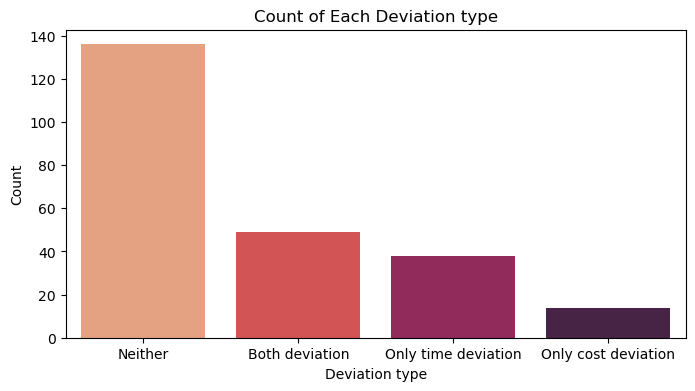

In [ ]:
# Create the histogram plot
sorted_counts = procesos_secop_i_data['DEVIATION_TYPE'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.countplot(data=procesos_secop_i_data,
              x='DEVIATION_TYPE',
              order=sorted_counts.index,
              palette='rocket_r')
plt.title('Count of Each Deviation type')
plt.xlabel('Deviation type')
plt.ylabel('Count')
plt.show()

c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


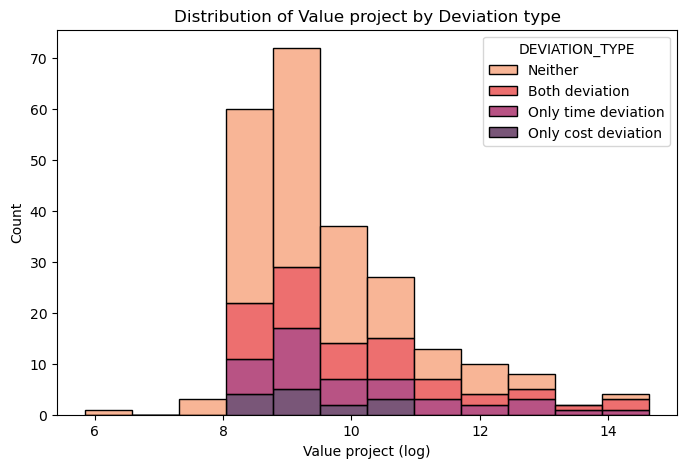

In [ ]:
procesos_secop_i_data['CONTRACT_VALUE_LOGNORM'] = np.log2(procesos_secop_i_data['CONTRACT_VALUE_NORM'])

plt.figure(figsize=(8, 5))
sns.histplot(data=procesos_secop_i_data,
             x='CONTRACT_VALUE_LOGNORM',
             hue='DEVIATION_TYPE',
             multiple='stack', palette='rocket_r', bins=12)

plt.title('Distribution of Value project by Deviation type')
plt.xlabel('Value project (log)')
#plt.legend(title='Deviation type'
           #, labels=procesos_secop_i_data['DEVIATION_TYPE'].value_counts().index
 #          )
plt.ylabel('Count')
plt.show()

c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


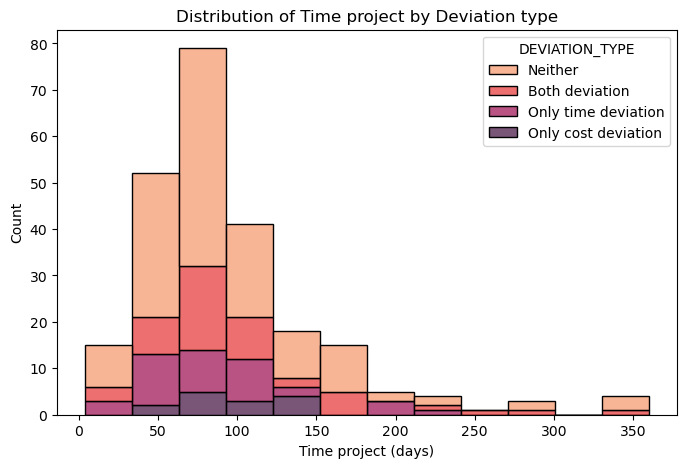

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=procesos_secop_i_data,
             x='ORIGINAL_DEADLINE',
             hue='DEVIATION_TYPE',
             multiple='stack', palette='rocket_r', bins=12)

plt.title('Distribution of Time project by Deviation type')
plt.xlabel('Time project (days)')
# plt.legend(title='Deviation type', labels=procesos_secop_i_data['DEVIATION_TYPE'].value_counts().index)
plt.ylabel('Count')
plt.show()

## Entity dimentions
### Municipality Type breakdown

* The 5 & 6 type are the unique categories where the adition projects is under 50%
* The other category has the highest value average project, but seems a missing data because the principal departments are incluided there (Bogotá, Antioquia, etc)

In [ ]:
procesos_secop_i_data.groupby(['MUNICIPALITY_TYPE', 'HAVE_DEVIATION']).apply(summary)

unique contracts  value norm avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION                                     
OTHER             False                       13.0     2758.394926   
                  True                        12.0     3103.132023   
TYPE_1            True                         2.0     2154.588854   
TYPE_2            False                       11.0      996.186713   
                  True                         8.0     3623.730698   
TYPE_3            False                        2.0     1681.319263   
                  True                         3.0     1385.343414   
TYPE_4            False                        2.0      788.720881   
                  True                         3.0      650.357908   
TYPE_5            False                        8.0      985.883218   
                  True                         9.0     4500.803783   
TYPE_6            False                      100.0      975.655577   
                  True                        64.0     1491.667958   

                                  cost deviation (%)  time duration avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION                                          
OTHER             False                     0.000000         126.538462   
                  True                      6.527802          96.250000   
TYPE_1            True                     40.971930          90.000000   
TYPE_2            False                     0.000000         119.363636   
                  True                      6.515175          91.875000   
TYPE_3            False                     0.000000         165.000000   
                  True                     21.839863          95.000000   
TYPE_4            False                     0.000000          70.000000   
                  True                     16.545860          80.000000   
TYPE_5            False                     0.000000          76.875000   
                  True                     35.284131         161.666667   
TYPE_6            False                     0.000000         103.250000   
                  True                     11.110185         104.812500   

                                  time deviation (%)  
MUNICIPALITY_TYPE HAVE_DEVIATION                      
OTHER             False                     0.000000  
                  True                     80.470679  
TYPE_1            True                    116.666667  
TYPE_2            False                     0.000000  
                  True                     69.970238  
TYPE_3            False                     0.000000  
                  True                     49.074074  
TYPE_4            False                     0.000000  
                  True                     64.444444  
TYPE_5            False                     0.000000  
                  True                     74.334215  
TYPE_6            False                     0.000000  
                  True                     86.210515

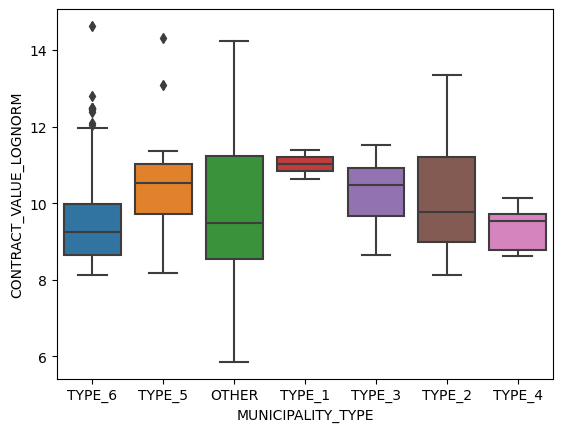

In [ ]:
sns.boxplot(x="MUNICIPALITY_TYPE", y="CONTRACT_VALUE_LOGNORM", data=procesos_secop_i_data)
plt.show()

In [ ]:
from scipy.stats import kruskal

def kruskal_test(data, groups, values):
    groups = data.groupby(groups)[values].apply(list)

    stat, p = kruskal(*groups)

    # Print the results
    print(f"Kruskal-Wallis H-statistic: {stat}")
    print(f"p-value: {p}")

print('Value project')
kruskal_test(procesos_secop_i_data, 'MUNICIPALITY_TYPE', 'CONTRACT_VALUE_LOGNORM')

print('Time durantion project')
kruskal_test(procesos_secop_i_data, 'MUNICIPALITY_TYPE', 'ORIGINAL_DEADLINE')

Value project
Kruskal-Wallis H-statistic: 15.359837920979489
p-value: 0.017635240387482414
Time durantion project
Kruskal-Wallis H-statistic: 4.8305104747126375
p-value: 0.5657281618123009


#### Detail for each adition type

In [ ]:
procesos_secop_i_data.groupby(['MUNICIPALITY_TYPE', 'HAVE_DEVIATION_COST']).apply(summary)

unique contracts  value norm avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION_COST                                     
OTHER             False                            23.0     2316.254212   
                  True                              2.0     9911.435710   
TYPE_1            True                              2.0     2154.588854   
TYPE_2            False                            16.0     1433.910619   
                  True                              3.0     5668.443172   
TYPE_3            False                             2.0     1681.319263   
                  True                              3.0     1385.343414   
TYPE_4            False                             4.0      783.706919   
                  True                              1.0      393.687810   
TYPE_5            False                             9.0     1170.624301   
                  True                              8.0     4732.335135   
TYPE_6            False                           120.0     1270.821743   
                  True                             44.0      921.220407   

                                       cost deviation (%)  time duration avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION_COST                                          
OTHER             False                          0.000000         103.478261   
                  True                          39.166810         210.000000   
TYPE_1            True                          40.971930          90.000000   
TYPE_2            False                          0.000000         113.937500   
                  True                          17.373801          75.000000   
TYPE_3            False                          0.000000         165.000000   
                  True                          21.839863          95.000000   
TYPE_4            False                          0.000000          83.750000   
                  True                          49.637581          45.000000   
TYPE_5            False                          0.000000          80.000000   
                  True                          39.694648         168.750000   
TYPE_6            False                          0.000000         103.941667   
                  True                          16.160269         103.636364   

                                       time deviation (%)  
MUNICIPALITY_TYPE HAVE_DEVIATION_COST                      
OTHER             False                         35.789050  
                  True                          71.250000  
TYPE_1            True                         116.666667  
TYPE_2            False                         24.568452  
                  True                          55.555556  
TYPE_3            False                          0.000000  
                  True                          49.074074  
TYPE_4            False                         31.666667  
                  True                          66.666667  
TYPE_5            False                          1.587302  
                  True                          81.840278  
TYPE_6            False                         23.940747  
                  True                          60.104167

In [ ]:
procesos_secop_i_data.groupby(['MUNICIPALITY_TYPE', 'HAVE_DEVIATION_TIME']).apply(summary)

unique contracts  value norm avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION_TIME                                     
OTHER             False                            13.0     2758.394926   
                  True                             12.0     3103.132023   
TYPE_1            True                              2.0     2154.588854   
TYPE_2            False                            12.0     1025.147372   
                  True                              7.0     3949.447280   
TYPE_3            False                             2.0     1681.319263   
                  True                              3.0     1385.343414   
TYPE_4            False                             2.0      788.720881   
                  True                              3.0      650.357908   
TYPE_5            False                             9.0     1040.608369   
                  True                              8.0     4878.603059   
TYPE_6            False                           112.0      936.081783   
                  True                             52.0     1695.983604   

                                       cost deviation (%)  time duration avg  \
MUNICIPALITY_TYPE HAVE_DEVIATION_TIME                                          
OTHER             False                          0.000000         126.538462   
                  True                           6.527802          96.250000   
TYPE_1            True                          40.971930          90.000000   
TYPE_2            False                          2.158743         113.166667   
                  True                           3.745212          98.571429   
TYPE_3            False                          0.000000         165.000000   
                  True                          21.839863          95.000000   
TYPE_4            False                          0.000000          70.000000   
                  True                          16.545860          80.000000   
TYPE_5            False                          3.336332          85.000000   
                  True                          35.941275         163.125000   
TYPE_6            False                          2.229347         103.973214   
                  True                           8.872403         103.615385   

                                       time deviation (%)  
MUNICIPALITY_TYPE HAVE_DEVIATION_TIME                      
OTHER             False                          0.000000  
                  True                          80.470679  
TYPE_1            True                         116.666667  
TYPE_2            False                          0.000000  
                  True                          79.965986  
TYPE_3            False                          0.000000  
                  True                          49.074074  
TYPE_4            False                          0.000000  
                  True                          64.444444  
TYPE_5            False                          0.000000  
                  True                          83.625992  
TYPE_6            False                          0.000000  
                  True                         106.105249

### Region breakdown
* The Andina region shows the most differents in the value of contrats and has the major number of projects
* The orinoquia have the inverse case of the region above

In [ ]:
procesos_secop_i_data.groupby(['REGION', 'HAVE_DEVIATION']).apply(summary)

unique contracts  value norm avg  \
REGION    HAVE_DEVIATION                                     
AMAZONIA  False                        5.0     1885.921410   
          True                         1.0     4209.237337   
ANDINA    False                       81.0     1024.959579   
          True                        59.0     2405.526810   
CARIBE    False                        3.0     2159.997671   
          True                         2.0    13037.497729   
ORINOQUIA False                        6.0     4473.198745   
          True                        11.0     1642.577028   
OTRA      False                       34.0      751.107370   
          True                        23.0      690.647415   
PACIFICA  False                        7.0      843.103237   
          True                         5.0     1290.828488   

                          cost deviation (%)  time duration avg  \
REGION    HAVE_DEVIATION                                          
AMAZONIA  False                     0.000000         162.000000   
          True                     18.326741         240.000000   
ANDINA    False                     0.000000         101.481481   
          True                     13.366521         109.135593   
CARIBE    False                     0.000000         210.000000   
          True                     23.932432          67.500000   
ORINOQUIA False                     0.000000         117.500000   
          True                     13.313601         120.000000   
OTRA      False                     0.000000          92.147059   
          True                     13.260579          79.521739   
PACIFICA  False                     0.000000         124.285714   
          True                      9.981165         159.000000   

                          time deviation (%)  
REGION    HAVE_DEVIATION                      
AMAZONIA  False                     0.000000  
          True                     87.500000  
ANDINA    False                     0.000000  
          True                     78.046353  
CARIBE    False                     0.000000  
          True                    237.500000  
ORINOQUIA False                     0.000000  
          True                     34.455267  
OTRA      False                     0.000000  
          True                    110.736715  
PACIFICA  False                     0.000000  
          True                     38.518519

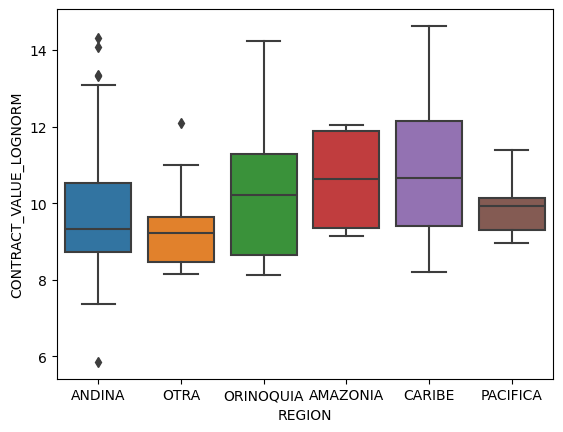

In [ ]:
sns.boxplot(x="REGION", y="CONTRACT_VALUE_LOGNORM", data=procesos_secop_i_data)
plt.show()

#### Detail for each adition type

In [ ]:
procesos_secop_i_data.groupby(['REGION', 'HAVE_DEVIATION_COST']).apply(summary)

unique contracts  value norm avg  \
REGION    HAVE_DEVIATION_COST                                     
AMAZONIA  False                             5.0     1885.921410   
          True                              1.0     4209.237337   
ANDINA    False                           103.0     1246.510181   
          True                             37.0     2609.655649   
CARIBE    False                             4.0     7967.782996   
          True                              1.0      683.856485   
ORINOQUIA False                             9.0     3449.459039   
          True                              8.0     1732.801053   
OTRA      False                            42.0      789.345482   
          True                             15.0      551.335393   
PACIFICA  False                            11.0     1078.107414   
          True                              1.0      496.683546   

                               cost deviation (%)  time duration avg  \
REGION    HAVE_DEVIATION_COST                                          
AMAZONIA  False                          0.000000         162.000000   
          True                          18.326741         240.000000   
ANDINA    False                          0.000000          99.553398   
          True                          21.314181         119.054054   
CARIBE    False                          0.000000         187.500000   
          True                          47.864864          15.000000   
ORINOQUIA False                          0.000000         111.666667   
          True                          18.306202         127.500000   
OTRA      False                          0.000000          88.738095   
          True                          20.332887          82.333333   
PACIFICA  False                          0.000000         137.727273   
          True                          49.905827         150.000000   

                               time deviation (%)  
REGION    HAVE_DEVIATION_COST                      
AMAZONIA  False                          0.000000  
          True                          87.500000  
ANDINA    False                         16.552172  
          True                          78.374625  
CARIBE    False                         68.750000  
          True                         200.000000  
ORINOQUIA False                         15.661376  
          True                          29.756944  
OTRA      False                         45.634921  
          True                          42.018519  
PACIFICA  False                         17.508418  
          True                           0.000000

In [ ]:
procesos_secop_i_data.groupby(['REGION', 'HAVE_DEVIATION_TIME']).apply(summary)

unique contracts  value norm avg  \
REGION    HAVE_DEVIATION_TIME                                     
AMAZONIA  False                             5.0     1885.921410   
          True                              1.0     4209.237337   
ANDINA    False                            85.0     1013.822612   
          True                             55.0     2523.143376   
CARIBE    False                             3.0     2159.997671   
          True                              2.0    13037.497729   
ORINOQUIA False                             7.0     4045.371721   
          True                             10.0     1658.993773   
OTRA      False                            42.0      726.359225   
          True                             15.0      727.696911   
PACIFICA  False                             8.0      799.800776   
          True                              4.0     1489.364724   

                               cost deviation (%)  time duration avg  \
REGION    HAVE_DEVIATION_TIME                                          
AMAZONIA  False                          0.000000         162.000000   
          True                          18.326741         240.000000   
ANDINA    False                          0.694778         102.000000   
          True                          13.264883         108.890909   
CARIBE    False                          0.000000         210.000000   
          True                          23.932432          67.500000   
ORINOQUIA False                          4.289569         122.142857   
          True                          11.642263         117.000000   
OTRA      False                          3.967376          92.809524   
          True                           9.224234          70.933333   
PACIFICA  False                          6.238228         127.500000   
          True                           0.000000         161.250000   

                               time deviation (%)  
REGION    HAVE_DEVIATION_TIME                      
AMAZONIA  False                          0.000000  
          True                          87.500000  
ANDINA    False                          0.000000  
          True                          83.722452  
CARIBE    False                          0.000000  
          True                         237.500000  
ORINOQUIA False                          0.000000  
          True                          37.900794  
OTRA      False                          0.000000  
          True                         169.796296  
PACIFICA  False                          0.000000  
          True                          48.148148

### Started Year breakdown

In [ ]:
procesos_secop_i_data.groupby(['YEAR', 'HAVE_DEVIATION']).apply(summary)

unique contracts  value norm avg  cost deviation (%)  \
YEAR HAVE_DEVIATION                                                         
2015 False                       32.0     1592.141021            0.000000   
     True                        20.0     2663.705263            9.881384   
2016 False                        9.0      943.981888            0.000000   
     True                        12.0     2587.706821           30.963268   
2017 False                       31.0      414.238607            0.000000   
     True                        17.0     1784.904275           11.162455   
2018 False                       24.0     1287.469495            0.000000   
     True                        15.0     1624.943434           20.244653   
2019 False                       20.0     1890.199772            0.000000   
     True                        18.0     1683.371485            8.347261   
2020 False                        5.0      849.220075            0.000000   
     True                         5.0     6003.717999            4.424037   
2021 False                       10.0      745.481337            0.000000   
     True                         9.0      783.196944           10.076965   
2022 False                        2.0     1400.688547            0.000000   
     True                         5.0     1241.106874            6.096616   
2023 False                        3.0      572.863673            0.000000   

                     time duration avg  time deviation (%)  
YEAR HAVE_DEVIATION                                         
2015 False                   89.687500            0.000000  
     True                    89.000000           83.916667  
2016 False                   98.333333            0.000000  
     True                    97.500000           67.268519  
2017 False                   78.548387            0.000000  
     True                    90.882353           52.343604  
2018 False                  138.750000            0.000000  
     True                   120.000000           61.425926  
2019 False                  148.550000            0.000000  
     True                   123.888889           76.427469  
2020 False                   77.000000            0.000000  
     True                   139.800000          104.855700  
2021 False                   93.800000            0.000000  
     True                    93.777778          218.868313  
2022 False                  150.000000            0.000000  
     True                   138.000000           23.841270  
2023 False                   84.666667            0.000000

c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


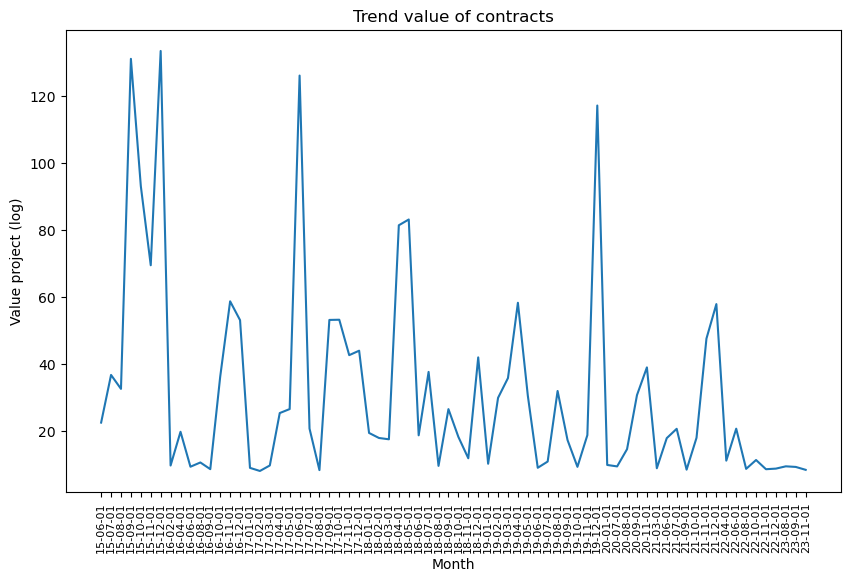

In [ ]:

procesos_secop_i_data['CONTRCT_MONTH_AT'] = procesos_secop_i_data['CONTRACT_DATE'].dt.to_period('M').dt.strftime('%y-%m-01')

summary_series = procesos_secop_i_data.groupby('CONTRCT_MONTH_AT')[['CONTRACT_VALUE_LOGNORM']].sum().reset_index()

# Initialize the plot
plt.figure(figsize=(10, 6))

# Create the time series plot
sns.lineplot(data=summary_series, x='CONTRCT_MONTH_AT', y='CONTRACT_VALUE_LOGNORM')

# Rotate the x-axis labels
plt.xticks(rotation=90, fontsize=8)

# Set title and labels
plt.title('Trend value of contracts')
plt.xlabel('Month')
plt.ylabel('Value project (log)')

# Show the plot
plt.show()

#### Detail for each adition type

In [ ]:
procesos_secop_i_data.groupby(['YEAR', 'HAVE_DEVIATION_COST']).apply(summary)

unique contracts  value norm avg  \
YEAR HAVE_DEVIATION_COST                                     
2015 False                            40.0     1977.457473   
     True                             12.0     2093.693250   
2016 False                            11.0      970.749176   
     True                             10.0     2887.007792   
2017 False                            39.0      493.114725   
     True                              9.0     2661.477244   
2018 False                            26.0     1236.935861   
     True                             13.0     1777.929769   
2019 False                            27.0     1905.076540   
     True                             11.0     1515.237780   
2020 False                             8.0     4013.238025   
     True                              2.0     1079.393084   
2021 False                            16.0      794.580746   
     True                              3.0      596.764644   
2022 False                             4.0     1651.227640   
     True                              3.0      800.666969   
2023 False                             3.0      572.863673   

                          cost deviation (%)  time duration avg  \
YEAR HAVE_DEVIATION_COST                                          
2015 False                          0.000000          86.500000   
     True                          16.468973          99.166667   
2016 False                          0.000000          90.000000   
     True                          37.155922         106.500000   
2017 False                          0.000000          75.897436   
     True                          21.084637         113.333333   
2018 False                          0.000000         135.000000   
     True                          23.359216         124.615385   
2019 False                          0.000000         145.592593   
     True                          13.659154         115.454545   
2020 False                          0.000000         101.750000   
     True                          11.060094         135.000000   
2021 False                          0.000000          94.500000   
     True                          30.230895          90.000000   
2022 False                          0.000000         157.500000   
     True                          10.161026         120.000000   
2023 False                          0.000000          84.666667   

                          time deviation (%)  
YEAR HAVE_DEVIATION_COST                      
2015 False                         27.180556  
     True                          49.259259  
2016 False                         16.969697  
     True                          62.055556  
2017 False                          6.990232  
     True                          68.580247  
2018 False                          3.205128  
     True                          64.465812  
2019 False                         10.462963  
     True                          99.381313  
2020 False                         60.673701  
     True                          19.444444  
2021 False                        112.974537  
     True                          54.074074  
2022 False                          6.190476  
     True                          31.481481  
2023 False                          0.000000

In [ ]:
procesos_secop_i_data.groupby(['YEAR', 'HAVE_DEVIATION_TIME']).apply(summary)

unique contracts  value norm avg  \
YEAR HAVE_DEVIATION_TIME                                     
2015 False                            35.0     1528.827941   
     True                             17.0     2983.155293   
2016 False                            11.0     1028.905563   
     True                             10.0     2823.035765   
2017 False                            34.0      416.925086   
     True                             14.0     2072.094040   
2018 False                            29.0     1164.953961   
     True                             10.0     2148.975453   
2019 False                            20.0     1890.199772   
     True                             18.0     1683.371485   
2020 False                             5.0      849.220075   
     True                              5.0     6003.717999   
2021 False                            11.0      722.863356   
     True                              8.0      819.011119   
2022 False                             2.0     1400.688547   
     True                              5.0     1241.106874   
2023 False                             3.0      572.863673   

                          cost deviation (%)  time duration avg  \
YEAR HAVE_DEVIATION_TIME                                          
2015 False                          1.553189          92.285714   
     True                           8.427414          83.529412   
2016 False                          5.084719          98.181818   
     True                          31.562731          97.500000   
2017 False                          1.833646          81.323529   
     True                           9.101268          86.785714   
2018 False                          2.864670         131.379310   
     True                          22.059438         132.000000   
2019 False                          0.000000         148.550000   
     True                           8.347261         123.888889   
2020 False                          0.000000          77.000000   
     True                           4.424037         139.800000   
2021 False                          4.536893          98.909091   
     True                           5.098357          86.750000   
2022 False                          0.000000         150.000000   
     True                           6.096616         138.000000   
2023 False                          0.000000          84.666667   

                          time deviation (%)  
YEAR HAVE_DEVIATION_TIME                      
2015 False                          0.000000  
     True                          98.725490  
2016 False                          0.000000  
     True                          80.722222  
2017 False                          0.000000  
     True                          63.560091  
2018 False                          0.000000  
     True                          92.138889  
2019 False                          0.000000  
     True                          76.427469  
2020 False                          0.000000  
     True                         104.855700  
2021 False                          0.000000  
     True                         246.226852  
2022 False                          0.000000  
     True                          23.841270  
2023 False                          0.000000

# Entity version

### Punishment last year

In [ ]:
ids_entidad = list(set(procesos_secop_i_data['NIT_ENTIDAD']))

ids_entidad = parse_to_list(ids_entidad)

# Get data
query = get_query('bin/queries', 'request_punishment_entity.sql')
query = query.format(NIT_ENTIDAD_LIST = ids_entidad)


temp_punishment_data = etl.extract_data(query, id_data=SECOPI_PUNISHMENT_API, api_key=None)
temp_punishment_data['PENALTY_DATE'] = pd.to_datetime(temp_punishment_data['PENALTY_DATE'])

temp_punishment_data.head()

El numero de contratos extraidos: 540


,PENALTY_ID,NIT_ENTIDAD,PENALTY_VALUE,PENALTY_DATE
0,20251456,No Definido,10000000,2024-11-19
1,20251456,No Definido,2000000,2024-12-28
2,147-2020,800100532-8,1658082,2021-05-06
3,06-334-2015,890204646-3,999055,2017-12-18
4,06-045-2019,890204646-3,15903790,2019-06-26


In [ ]:
# entidad
temp_punishment_entidad_data = pd.merge(procesos_secop_i_data[['CONTRACT_ID','NIT_ENTIDAD','CONTRACT_DATE','END_DATE']], temp_punishment_data,
                                    how='inner', on='NIT_ENTIDAD')

def penalty_summary(x,pref):
    data = {}

    data['NUM_PENALTIES' + pref] = x['PENALTY_ID'].size
    #data['VAL_PENALTIES'] = x['PENALTY_VALUE'].sum()
    return pd.Series(data)

temp_punishment_entidad_last = temp_punishment_entidad_data[(temp_punishment_entidad_data['CONTRACT_DATE'] > temp_punishment_entidad_data['PENALTY_DATE']) &
                                                            (temp_punishment_entidad_data['PENALTY_DATE'] > (temp_punishment_entidad_data['CONTRACT_DATE'] - pd.DateOffset(years=1)))]\
                                                                .drop_duplicates().groupby('CONTRACT_ID').apply(penalty_summary, '_ENTIDAD_LAST_Y')

procesos_secop_i_data.reset_index(drop = True, inplace = True)
temp_punishment_entidad_last.reset_index(inplace = True)

procesos_secop_i_data = pd.merge(procesos_secop_i_data,
                                 temp_punishment_entidad_last,
                                 how='left', on='CONTRACT_ID')

procesos_secop_i_data['NUM_PENALTIES_ENTIDAD_LAST_Y'] = procesos_secop_i_data['NUM_PENALTIES_ENTIDAD_LAST_Y'].fillna(0)

In [ ]:
def summary_punishment(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['value average'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation'] = x['COST_DEVIATION_NORM'].mean()
    data['time deviation'] = x['TIME_DEVIATION'].mean()
    data['avg penalties to entity last year'] = x['NUM_PENALTIES_ENTIDAD_LAST_Y'].mean()
    data['var penalties to entity last year'] = x['NUM_PENALTIES_ENTIDAD_LAST_Y'].std()

    return pd.Series(data)

procesos_secop_i_data.groupby('HAVE_DEVIATION').apply(summary_punishment)

,unique contracts,value average,cost deviation,time deviation,avg penalties to entity last year,var penalties to entity last year
HAVE_DEVIATION,,,,,,
False,136.0,1155.955086,0.000000,0.000000,3.419118,14.186355
True,101.0,2105.125692,0.134274,0.820374,4.970297,15.964621


<Axes: >

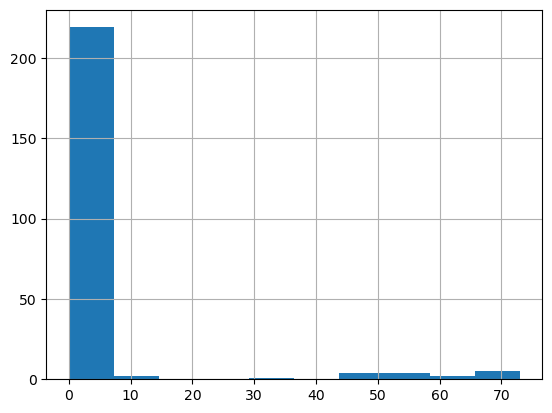

In [ ]:
procesos_secop_i_data.NUM_PENALTIES_ENTIDAD_LAST_Y.hist()

In [ ]:
np.sum(procesos_secop_i_data['NUM_PENALTIES_ENTIDAD_LAST_Y'] == 0)

211

### Time or cost deviation in the past

In [ ]:
# Get data
ids_entidad = list(set(procesos_secop_i_data['NIT_ENTIDAD']))

batch = 1

split_list = len(ids_entidad) // batch

temp_adition_historical = pd.DataFrame()

for i in range(batch):
    starts = (i*split_list)
    ends = (i+1)*split_list

    if i == (batch - 1):
        list_entidades = parse_to_list(ids_entidad[starts:])
    else:
        list_entidades = parse_to_list(ids_entidad[starts:ends])

    query = get_query('bin/queries', 'request_historical_data_si_entity_v2.sql')
    query = query.format(NIT_ENTIDAD_LIST = list_entidades)

    temp_adition_historical_batch = etl.extract_data(query, id_data=SECOPI_PROCESS_API)

    temp_adition_historical = pd.concat([temp_adition_historical, temp_adition_historical_batch])

def currency_standarize(df, cuantia_col):

    salario_minimo = {2012:566664,
                        2013:589000,
                        2014:616000,
                        2015:644350,
                        2016:689455,
                        2017:737717,
                        2018:781242,
                        2019:828116,
                        2020:877803,
                        2021:908526,
                        2022:1000000,
                        2023:1160000,
                        2024:1300000}

    for col in cuantia_col:
        temp = [val/salario_minimo[anno] for val,anno in zip(df[col],df['YEAR_AT'])]
        df[col.replace("_ORIG", "_NORM")] = temp
        del temp

    return df

temp_adition_historical.head(10)

El numero de contratos extraidos: 30711


,NIT_ENTIDAD,FECHA_FIRMA,YEAR_AT,UID,COST_ADITION,TIME_ADITION,ESTIMATED_VALUE,REAL_VALE,ORIGINAL_DEADLINE
0,591500887-4,2014-03-14T00:00:00.000,2014,13-11-2170245-2358451,0,0,129372276,129105100,90
1,591500887-4,2014-08-01T00:00:00.000,2014,14-1-121010-2670737,0,0,252664652,239891006,90
2,591500887-4,2014-08-05T00:00:00.000,2014,14-1-121295-2670766,0,0,180000000,180000000,90
3,591500887-4,2014-09-02T00:00:00.000,2014,14-11-2824297-2727017,0,0,49997294,49601379,45
4,591500887-4,2015-05-20T00:00:00.000,2015,15-11-3758510-3583882,0,0,50000000,49900000,60
5,591500887-4,2015-06-01T00:00:00.000,2015,15-11-3758479-3622651,0,0,69999975,69999973,60
6,591500887-4,2015-07-02T00:00:00.000,2015,15-11-3909241-3731472,0,0,44424066,44346780,20
7,591500887-4,2015-07-10T00:00:00.000,2015,15-1-140252-3780971,0,0,194392522,194294722,75
8,591500887-4,2015-07-14T00:00:00.000,2015,15-11-3957322-3767263,0,0,44934769,44901161,60
9,591500887-4,2015-07-28T00:00:00.000,2015,15-11-4016386-3800114,0,0,79950000,79928505,60


In [ ]:
interested_col = ['YEAR_AT','COST_ADITION', 'TIME_ADITION','ESTIMATED_VALUE', 'REAL_VALE', 'ORIGINAL_DEADLINE']
for col in interested_col:
    temp_adition_historical[col] = pd.to_numeric(temp_adition_historical[col])

temp_adition_historical = currency_standarize(temp_adition_historical, ['COST_ADITION','ESTIMATED_VALUE', 'REAL_VALE'])

In [ ]:
temp_adition_historical['REAL_VALE_LOG'] = np.log2(temp_adition_historical['REAL_VALE'])
temp_adition_historical['AWARD_GROWTH'] = (temp_adition_historical['ESTIMATED_VALUE'] - temp_adition_historical['REAL_VALE'])/(temp_adition_historical['ESTIMATED_VALUE'] +1)
temp_adition_historical['PROJECT_INTENSINTY'] = temp_adition_historical['REAL_VALE_LOG'] / (temp_adition_historical['ORIGINAL_DEADLINE'] + 1)
temp_adition_historical['COST_DEVIATION'] = temp_adition_historical['COST_ADITION'] / temp_adition_historical['REAL_VALE']
temp_adition_historical['TIME_DEVIATION'] = temp_adition_historical['TIME_ADITION'] / temp_adition_historical['ORIGINAL_DEADLINE']

In [ ]:
temp_adition_historical['TIME_DEVIATION'] = temp_adition_historical['TIME_DEVIATION'].fillna(0)

In [ ]:
from sklearn.svm import OneClassSVM

# Define the model
svm = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)  # 'nu' is the proportion of outliers

interested_columns = ['REAL_VALE_LOG', 'AWARD_GROWTH','PROJECT_INTENSINTY', 'COST_DEVIATION', 'TIME_DEVIATION']
y_pred = svm.fit_predict(temp_adition_historical[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical['OUTLIER_M1'] = y_pred

In [ ]:
from sklearn.ensemble import IsolationForest

# Define the model
iso_forest = IsolationForest(contamination=0.1)  # contamination is the expected proportion of outliers
y_pred = iso_forest.fit_predict(temp_adition_historical[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical['OUTLIER_M2'] = y_pred

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Define the model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(temp_adition_historical[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical['OUTLIER_M3'] = y_pred

In [ ]:
temp_adition_historical['OUTLIER_M1'] = np.where(temp_adition_historical['OUTLIER_M1'] == -1, 1, 0)
temp_adition_historical['OUTLIER_M2'] = np.where(temp_adition_historical['OUTLIER_M2'] == -1, 1, 0)
temp_adition_historical['OUTLIER_M3'] = np.where(temp_adition_historical['OUTLIER_M3'] == -1, 1, 0)

In [ ]:
temp_adition_historical['OUTLIER_RESULT'] = temp_adition_historical['OUTLIER_M1'] + temp_adition_historical['OUTLIER_M2']+ temp_adition_historical['OUTLIER_M3']

In [ ]:
temp_adition_historical.groupby('OUTLIER_RESULT').size()

OUTLIER_RESULT
0    23772
1     4924
2     1756
3      259
dtype: int64

In [ ]:
temp_adition_historical['OUTLIER'] = (temp_adition_historical['OUTLIER_RESULT'] > 1)  | (temp_adition_historical['OUTLIER_M1'] > 0)
temp_adition_historical = temp_adition_historical[-temp_adition_historical['OUTLIER']]

In [ ]:
temp_adition_historical['PROJECTS_W_BOTH_ADITION'] = (temp_adition_historical['COST_DEVIATION'] > 0) & (temp_adition_historical['TIME_DEVIATION'] > 0)
temp_adition_historical['PROJECTS_W_COST_ADITION'] = (temp_adition_historical['COST_DEVIATION'] > 0)
temp_adition_historical['PROJECTS_W_TIME_ADITION'] = (temp_adition_historical['TIME_DEVIATION'] > 0)

In [ ]:
temp_adition_historical['FECHA_FIRMA'] = pd.to_datetime(temp_adition_historical['FECHA_FIRMA'])
procesos_secop_i_data['CONTRACT_DATE'] = pd.to_datetime(procesos_secop_i_data['CONTRACT_DATE'])

merged_df = pd.merge(procesos_secop_i_data, temp_adition_historical, how='inner', on='NIT_ENTIDAD',
                     left_index=False, right_index=False, sort=False)

# Filter the merged DataFrame to include only rows where the date falls within the range of stated_at and ended_at columns
merged_df = merged_df[merged_df['FECHA_FIRMA'] < merged_df['CONTRACT_DATE']]

In [ ]:
merged_df.to_clipboard()

In [ ]:
temp_adition_historical['FECHA_FIRMA'] = pd.to_datetime(temp_adition_historical['FECHA_FIRMA'])
procesos_secop_i_data['CONTRACT_DATE'] = pd.to_datetime(procesos_secop_i_data['CONTRACT_DATE'])

merged_df = pd.merge(procesos_secop_i_data, temp_adition_historical, how='inner', on='NIT_ENTIDAD',
                     left_index=False, right_index=False, sort=False)

# Filter the merged DataFrame to include only rows where the date falls within the range of stated_at and ended_at columns
merged_df = merged_df[merged_df['FECHA_FIRMA'] < merged_df['CONTRACT_DATE']]

def proportion_cost_adition(x, subjet):
    data = {}

    # Sum of 'PROJECTS_W_BOTH_ADITION' and 'PROJECTS'
    contracts_w_deviations = x['PROJECTS_W_BOTH_ADITION'].sum()
    contracts_w_cost = x['PROJECTS_W_COST_ADITION'].sum()
    contracts_w_time = x['PROJECTS_W_TIME_ADITION'].sum()
    total_contracts = x['UID'].drop_duplicates().size

    # Check for division by zero
    if total_contracts != 0:
        proportion_overall = contracts_w_deviations / total_contracts
        proportion_cost = contracts_w_cost / total_contracts
        proportion_time = contracts_w_time / total_contracts
    else:
        proportion_overall = 0
        proportion_cost = 0
        proportion_time = 0



    # Calculate award growth
    #df['AWARD_GROWTH_NORM'] = ((df['CONTRACT_VALUE_NORM'] - df['ESTIMATED_COST_NORM'])/df['ESTIMATED_COST_NORM'])


    # data['deviations'] = contracts_w_deviations
    data['TOTAL_CONTRACTS_OBRAS_' + subjet] = total_contracts
    data['PROPORTION_DEVIATION_'+ subjet +'_ALL_TIME'] = proportion_overall
    data['PROPORTION_COST_DEVIATION_'+ subjet +'_ALL_TIME'] = proportion_cost
    data['PROPORTION_TIME_DEVIATION_'+ subjet +'_ALL_TIME'] = proportion_time

    data['PROJECT_INTENSITY_NORM_'+ subjet +'_ALL_TIME'] = x['REAL_VALE'].sum()/x['ORIGINAL_DEADLINE_y'].sum()
    data['AWARD_GROWTH_ORIG_'+ subjet +'_ALL_TIME'] = ((x['REAL_VALE'].sum() - x['ESTIMATED_VALUE'].sum())/x['ESTIMATED_VALUE'].sum())

    return pd.Series(data)

merged_df = merged_df.groupby('CONTRACT_ID').apply(lambda x: proportion_cost_adition(x, 'ENTITY'))

merged_df = merged_df.reset_index()
merged_df.head()

procesos_secop_i_data = pd.merge(procesos_secop_i_data,
                                 merged_df,
                                 how='left', on='CONTRACT_ID')

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   CONTRACT_ID                                233 non-null    object 
 1   TOTAL_CONTRACTS_OBRAS_ENTITY               233 non-null    float64
 2   PROPORTION_DEVIATION_ENTITY_ALL_TIME       233 non-null    float64
 3   PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME  233 non-null    float64
 4   PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME  233 non-null    float64
 5   PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME     233 non-null    float64
 6   AWARD_GROWTH_ORIG_ENTITY_ALL_TIME          233 non-null    float64
dtypes: float64(6), object(1)
memory usage: 12.9+ KB


In [ ]:
def summary_deviation(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['unique entities'] = x['NIT_ENTIDAD'].drop_duplicates().size
    data['value average'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation'] = x['COST_DEVIATION_NORM'].mean()
    data['time deviation'] = x['TIME_DEVIATION'].mean()
    data['avg total contracts'] = x['TOTAL_CONTRACTS_OBRAS_ENTITY'].mean()
    data['avg deviation to entity last year'] = x['PROPORTION_DEVIATION_ENTITY_ALL_TIME'].mean()
    data['avg cost deviation to entity last year'] = x['PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME'].mean()
    data['avg time deviation to entity last year'] = x['PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME'].mean()
    data['avg project intensity last year'] = x['PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME'].mean()
    data['avg award growth last year'] = x['AWARD_GROWTH_ORIG_ENTITY_ALL_TIME'].mean()

    return pd.Series(data)

procesos_secop_i_data.groupby('HAVE_DEVIATION').apply(summary_deviation)

,unique contracts,unique entities,value average,cost deviation,time deviation,avg total contracts,avg deviation to entity last year,avg cost deviation to entity last year,avg time deviation to entity last year,avg project intensity last year,avg award growth last year
HAVE_DEVIATION,,,,,,,,,,,
False,136.0,93.0,1155.955086,0.000000,0.000000,322.231343,0.111927,0.163419,0.170874,6.149013,-0.003904
True,101.0,63.0,2105.125692,0.134274,0.820374,523.767677,0.154351,0.227998,0.235563,6.767930,-0.005531


0


<Axes: >

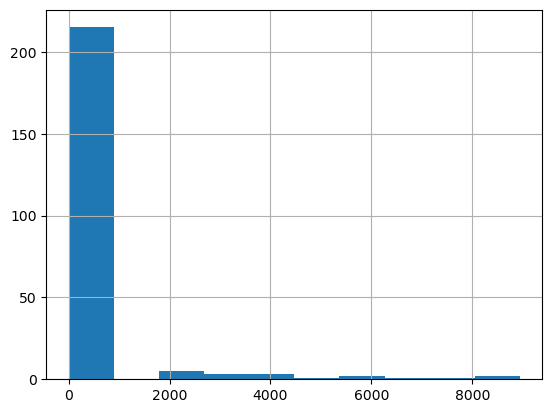

In [ ]:
print(np.sum(procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_ENTITY'] == 0))
procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_ENTITY'][procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_ENTITY'] > 0].hist()

36


<Axes: >

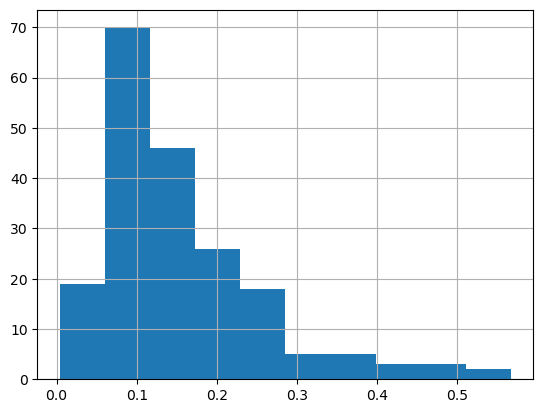

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_DEVIATION_ENTITY_ALL_TIME'] == 0))
procesos_secop_i_data['PROPORTION_DEVIATION_ENTITY_ALL_TIME'][procesos_secop_i_data['PROPORTION_DEVIATION_ENTITY_ALL_TIME'] > 0].hist()

24


<Axes: >

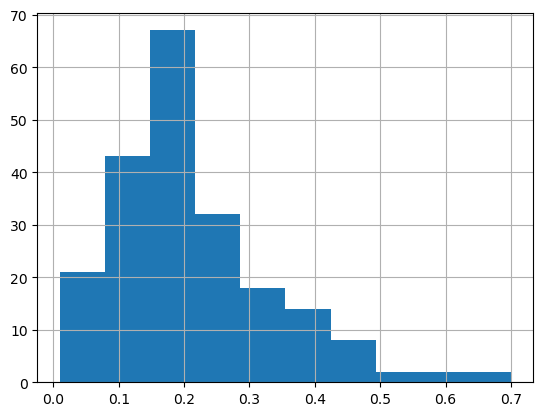

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME'] == 0))
procesos_secop_i_data['PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME'][procesos_secop_i_data['PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME'] > 0].hist()

23


<Axes: >

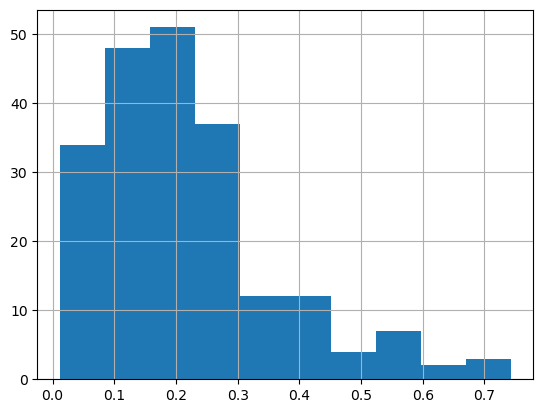

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME'] == 0))
procesos_secop_i_data['PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME'][procesos_secop_i_data['PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME'] > 0].hist()

0


<Axes: >

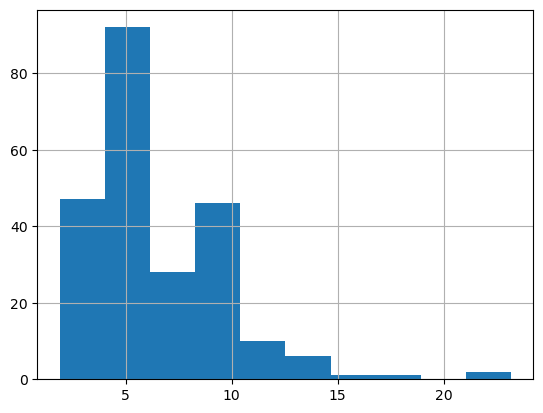

In [ ]:
print(np.sum(procesos_secop_i_data['PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME'] == 0))
procesos_secop_i_data['PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME'][procesos_secop_i_data['PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME'] > 0].hist()

0


<Axes: >

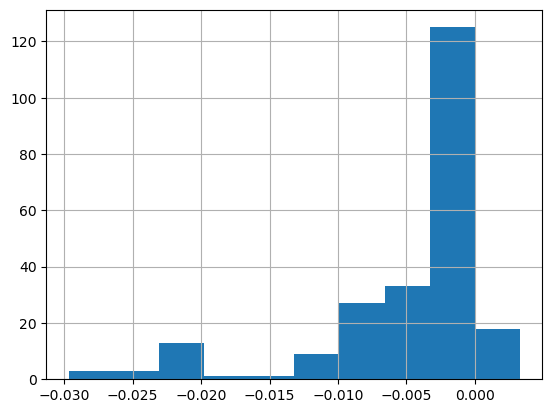

In [ ]:
print(np.sum(procesos_secop_i_data['AWARD_GROWTH_ORIG_ENTITY_ALL_TIME'] == 0))
procesos_secop_i_data['AWARD_GROWTH_ORIG_ENTITY_ALL_TIME'].hist()

## Supplier version

### Punishment last year

In [ ]:
supplier_data = pd.read_csv(get_path('data', 'suppliers_list_secop_standarized.csv'))


ids_contratistas = list(set(supplier_data['id_contratista_other_versions']))
names_contratistas = list(set(supplier_data['nom_contratista_other_versions']))

ids_contratistas = parse_to_list(ids_contratistas)
names_contratistas = parse_to_list(names_contratistas)

# Get data
query = get_query('bin/queries', 'request_punishment_supplier.sql')
query = query.format(ID_CONTRATISTA = ids_contratistas, NAME_CONTRATISTA = names_contratistas)


temp_punishment_data = etl.extract_data(query, id_data=SECOPI_PUNISHMENT_API, api_key=None)
# temp_punishment_data['PENALTY_DATE'] = pd.to_datetime(temp_punishment_data['PENALTY_DATE'])

#temp_punishment_data.head()

El numero de contratos extraidos: 0


### Time or cost deviation in the past year

In [ ]:
supplier_data = pd.read_csv(get_path('data', 'suppliers_list_secop_standarized.csv'))

# supplier_data['key_others_version'] = supplier_data['id_contratista_other_versions']

ids_contratistas = list(set(supplier_data['id_contratista_other_versions']))
names_contratistas = list(set(supplier_data['nom_contratista_other_versions']))

list_contratistas_ids = parse_to_list(ids_contratistas)

list_contratistas_names = parse_to_list(names_contratistas)

query = get_query('bin/queries', 'request_historical_data_si_supplier_v2.sql')
query = query.format(ID_CONTRATISTA = list_contratistas_ids, NAME_CONTRATISTA = list_contratistas_names)

temp_adition_historical_supplier = etl.extract_data(query, id_data=SECOPI_PROCESS_API)

# temp_adition_historical_supplier = pd.concat([temp_adition_historical_supplier, temp_adition_historical_supplier_batch])

temp_adition_historical_supplier.head()

El numero de contratos extraidos: 2259


,ID_CONTRATISTA_NET,NAME_CONTRATISTA_NET,FECHA_FIRMA,YEAR_AT,UID,COST_ADITION,TIME_ADITION,ESTIMATED_VALUE,REAL_VALE,ORIGINAL_DEADLINE
0,80388550,JOSE LUIS MORALES BOLANOS,2018-11-15T00:00:00.000,2018,18-11-8573961-7884197,0,0,181500000,181488363,75
1,900902330-1,UNION TEMPORAL FISTEGA,2015-10-26T00:00:00.000,2015,15-1-147652-4032692,0,0,700459984,700459984,120
2,804010292,EMPRESA ASOCIATIVA DE TRABAJO DE BIENES Y SERVICIOS DE SANTANDER. SERBISAN,2019-11-20T00:00:00.000,2019,19-11-9978088-9222502,0,0,110004199,109897361,40
3,901063647,CONSTRUCTORA PAIS SAS,2018-07-19T00:00:00.000,2018,18-21-3606-7950076,0,0,558878527,558825241,120
4,7168649,EDBIN GUILLERMO AVILA FONSECA,2018-04-13T00:00:00.000,2018,18-11-7949806-7498890,49969805,0,218367363,217998966,180


In [ ]:
interested_col = ['YEAR_AT','COST_ADITION', 'TIME_ADITION','ESTIMATED_VALUE', 'REAL_VALE', 'ORIGINAL_DEADLINE']
for col in interested_col:
    temp_adition_historical_supplier[col] = pd.to_numeric(temp_adition_historical_supplier[col])

temp_adition_historical_supplier = currency_standarize(temp_adition_historical_supplier, ['COST_ADITION','ESTIMATED_VALUE', 'REAL_VALE'])

In [ ]:
temp_adition_historical_supplier['REAL_VALE_LOG'] = np.log2(temp_adition_historical_supplier['REAL_VALE'])
temp_adition_historical_supplier['AWARD_GROWTH'] = (temp_adition_historical_supplier['ESTIMATED_VALUE'] - temp_adition_historical_supplier['REAL_VALE'])/(temp_adition_historical_supplier['ESTIMATED_VALUE'] +1)
temp_adition_historical_supplier['PROJECT_INTENSINTY'] = temp_adition_historical_supplier['REAL_VALE_LOG'] / (temp_adition_historical_supplier['ORIGINAL_DEADLINE'] + 1)
temp_adition_historical_supplier['COST_DEVIATION'] = temp_adition_historical_supplier['COST_ADITION'] / temp_adition_historical_supplier['REAL_VALE']
temp_adition_historical_supplier['TIME_DEVIATION'] = temp_adition_historical_supplier['TIME_ADITION'] / temp_adition_historical_supplier['ORIGINAL_DEADLINE']

In [ ]:
temp_adition_historical_supplier['TIME_DEVIATION'] = temp_adition_historical_supplier['TIME_DEVIATION'].fillna(0)

In [ ]:
from sklearn.svm import OneClassSVM

# Define the model
svm = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)  # 'nu' is the proportion of outliers

interested_columns = ['REAL_VALE_LOG', 'AWARD_GROWTH','PROJECT_INTENSINTY', 'COST_DEVIATION', 'TIME_DEVIATION']
y_pred = svm.fit_predict(temp_adition_historical_supplier[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical_supplier['OUTLIER_M1'] = y_pred

In [ ]:
from sklearn.ensemble import IsolationForest

# Define the model
iso_forest = IsolationForest(contamination=0.1)  # contamination is the expected proportion of outliers
y_pred = iso_forest.fit_predict(temp_adition_historical_supplier[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical_supplier['OUTLIER_M2'] = y_pred

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Define the model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(temp_adition_historical_supplier[interested_columns])

# Output: -1 for outliers, 1 for inliers
temp_adition_historical_supplier['OUTLIER_M3'] = y_pred

In [ ]:
temp_adition_historical_supplier['OUTLIER_M1'] = np.where(temp_adition_historical_supplier['OUTLIER_M1'] == -1, 1, 0)
temp_adition_historical_supplier['OUTLIER_M2'] = np.where(temp_adition_historical_supplier['OUTLIER_M2'] == -1, 1, 0)
temp_adition_historical_supplier['OUTLIER_M3'] = np.where(temp_adition_historical_supplier['OUTLIER_M3'] == -1, 1, 0)

In [ ]:
temp_adition_historical_supplier['OUTLIER_RESULT'] = temp_adition_historical_supplier['OUTLIER_M1'] + temp_adition_historical_supplier['OUTLIER_M2']+ temp_adition_historical_supplier['OUTLIER_M3']

In [ ]:
temp_adition_historical_supplier.groupby('OUTLIER_RESULT').size()

OUTLIER_RESULT
0    1777
1     323
2     120
3      39
dtype: int64

In [ ]:
temp_adition_historical_supplier['OUTLIER'] = (temp_adition_historical_supplier['OUTLIER_RESULT'] > 1)  | (temp_adition_historical_supplier['OUTLIER_M1'] > 0)
temp_adition_historical_supplier = temp_adition_historical_supplier[-temp_adition_historical_supplier['OUTLIER']]

In [ ]:
temp_adition_historical_supplier['PROJECTS_W_BOTH_ADITION'] = (temp_adition_historical_supplier['COST_DEVIATION'] > 0) & (temp_adition_historical_supplier['TIME_DEVIATION'] > 0)
temp_adition_historical_supplier['PROJECTS_W_COST_ADITION'] = (temp_adition_historical_supplier['COST_DEVIATION'] > 0)
temp_adition_historical_supplier['PROJECTS_W_TIME_ADITION'] = (temp_adition_historical_supplier['TIME_DEVIATION'] > 0)

In [ ]:
temp_adition_historical_supplier['FECHA_FIRMA'] = pd.to_datetime(temp_adition_historical_supplier['FECHA_FIRMA'])


merged_df = pd.merge(supplier_data, temp_adition_historical_supplier, how='inner',
                     left_on=['id_contratista_other_versions', 'nom_contratista_other_versions'],
                     right_on=['ID_CONTRATISTA_NET', 'NAME_CONTRATISTA_NET'],
                     left_index=False, right_index=False, sort=False)

In [ ]:
merged_df.to_clipboard()

In [ ]:
temp_adition_historical_supplier['FECHA_FIRMA'] = pd.to_datetime(temp_adition_historical_supplier['FECHA_FIRMA'])


merged_df = pd.merge(supplier_data, temp_adition_historical_supplier, how='inner',
                     left_on=['id_contratista_other_versions', 'nom_contratista_other_versions'],
                     right_on=['ID_CONTRATISTA_NET', 'NAME_CONTRATISTA_NET'],
                     left_index=False, right_index=False, sort=False)

# def summary_cont_hist(x):
#     data = {}
#     data['PROJECTS'] = x['PROJECTS'].sum()
#     data['PROJECTS_W_COST_ADITION'] = x['PROJECTS_W_COST_ADITION'].sum()
#     data['PROJECTS_W_TIME_ADITION'] = x['PROJECTS_W_TIME_ADITION'].sum()
#     data['PROJECTS_W_BOTH_ADITION'] = x['PROJECTS_W_BOTH_ADITION'].sum()
#     data['SUM_ESTIMATED_COST_ORIG'] = x['SUM_ESTIMATED_COST_ORIG'].sum()
#     data['SUM_CONTRACT_VALUE_ORIG'] = x['SUM_CONTRACT_VALUE_ORIG'].sum()
#     data['SUM_ORIGINAL_DEADLINE'] = x['SUM_ORIGINAL_DEADLINE'].sum()

#     return pd.Series(data)

# merged_df = merged_df.groupby(['ID_CONTRATISTA', 'NOM_CONTRATISTA', 'MONTH_AT', 'YEAR_AT']).apply(summary_cont_hist).reset_index()

# merged_df = currency_standarize(merged_df, ['SUM_ESTIMATED_COST_ORIG', 'SUM_CONTRACT_VALUE_ORIG'])


merged_df = pd.merge(procesos_secop_i_data, merged_df, how='inner',
                     left_on=['ID_CONTRATISTA', 'NOM_CONTRATISTA'],
                     right_on=['ID_CONTRATISTA', 'NOM_CONTRATISTA'],
                     left_index=False, right_index=False, sort=False)

# Filter the merged DataFrame to include only rows where the date falls within the range of stated_at and ended_at columns
merged_df = merged_df[(merged_df['FECHA_FIRMA'] < merged_df['CONTRACT_DATE'])]

# def proportion_cost_adition(x):
#     data = {}

#     # Convert columns to numeric data types
#     x['PROJECTS_W_BOTH_ADITION'] = pd.to_numeric(x['PROJECTS_W_BOTH_ADITION'], errors='coerce')
#     x['PROJECTS'] = pd.to_numeric(x['PROJECTS'], errors='coerce')

#     # Sum of 'PROJECTS_W_BOTH_ADITION' and 'PROJECTS'
#     contracts_w_deviations = x['PROJECTS_W_BOTH_ADITION'].sum()
#     total_contracts = x['PROJECTS'].sum()

#     # Check for division by zero
#     if total_contracts != 0:
#         proportion = contracts_w_deviations / total_contracts
#     else:
#         proportion = None



#     # Calculate award growth
#     #df['AWARD_GROWTH_NORM'] = ((df['CONTRACT_VALUE_NORM'] - df['ESTIMATED_COST_NORM'])/df['ESTIMATED_COST_NORM'])


#     # data['deviations'] = contracts_w_deviations
#     data['TOTAL_CONTRACTS_OBRAS_CONT'] = total_contracts
#     data['PROPORTION_DEVIATIONS_CONT_LAST_Y'] = proportion

#     data['PROJECT_INTENSITY_NORM_CONT_LAST_Y'] = x['SUM_ESTIMATED_COST_ORIG'].sum()/x['SUM_CONTRACT_VALUE_ORIG'].sum()
#     data['AWARD_GROWTH_ORIG_LAST_CONT_Y'] = ((x['SUM_CONTRACT_VALUE_ORIG'].sum() - x['SUM_ESTIMATED_COST_ORIG'].sum())/x['SUM_ESTIMATED_COST_ORIG'].sum())

#     return pd.Series(data)

merged_df = merged_df.groupby('CONTRACT_ID').apply(lambda x: proportion_cost_adition(x, 'CONT'))

merged_df = merged_df.reset_index()
merged_df.head()

,CONTRACT_ID,TOTAL_CONTRACTS_OBRAS_CONT,PROPORTION_DEVIATION_CONT_ALL_TIME,PROPORTION_COST_DEVIATION_CONT_ALL_TIME,PROPORTION_TIME_DEVIATION_CONT_ALL_TIME,PROJECT_INTENSITY_NORM_CONT_ALL_TIME,AWARD_GROWTH_ORIG_CONT_ALL_TIME
0,15-1-138416-3768277,4.0,0.000000,0.250000,0.000000,14.416154,-1.414804e-02
1,15-1-139585-5072554,7.0,0.285714,0.285714,0.285714,4.802125,-3.989879e-10
2,15-1-148714-4032288,18.0,0.111111,0.111111,0.333333,4.231778,2.817403e-03
3,15-1-150895-5650065,1.0,0.000000,0.000000,0.000000,1.509740,-9.461470e-05
4,16-1-161867-6353427,1.0,0.000000,0.000000,0.000000,8.621953,0.000000e+00


In [ ]:
procesos_secop_i_data = procesos_secop_i_data.drop(['TOTAL_CONTRACTS_OBRAS_CONT_x',
       'PROPORTION_DEVIATION_CONT_ALL_TIME_x',
       'PROPORTION_COST_DEVIATION_CONT_ALL_TIME_x',
       'PROPORTION_TIME_DEVIATION_CONT_ALL_TIME_x',
       'PROJECT_INTENSITY_NORM_CONT_ALL_TIME_x',
       'AWARD_GROWTH_ORIG_CONT_ALL_TIME_x', 'TOTAL_CONTRACTS_OBRAS_CONT_y',
       'PROPORTION_DEVIATION_CONT_ALL_TIME_y',
       'PROPORTION_COST_DEVIATION_CONT_ALL_TIME_y',
       'PROPORTION_TIME_DEVIATION_CONT_ALL_TIME_y',
       'PROJECT_INTENSITY_NORM_CONT_ALL_TIME_y',
       'AWARD_GROWTH_ORIG_CONT_ALL_TIME_y'], axis=1)

In [ ]:
procesos_secop_i_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 51 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   CONTRACT_ID                                237 non-null    object        
 1   ENTITY_NAME                                237 non-null    object        
 2   DEPARTMENT                                 237 non-null    object        
 3   MUNICIPALITY_TYPE                          237 non-null    object        
 4   PROCESS_TYPE                               237 non-null    object        
 5   CONTRACT_OBJECT                            237 non-null    object        
 6   OBJETC_DETAIL                              237 non-null    object        
 7   ESTIMATED_COST_ORIG                        237 non-null    float64       
 8   CONTRACT_VALUE_ORIG                        237 non-null    float64       
 9   ADDITIONAL_COST_ORIG 

In [ ]:
procesos_secop_i_data = pd.merge(procesos_secop_i_data,
                                 merged_df,
                                 how='left', on='CONTRACT_ID')

def summary_deviation(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['unique entities'] = x['NIT_ENTIDAD'].drop_duplicates().size
    data['value average'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation'] = x['COST_DEVIATION_NORM'].mean()
    data['time deviation'] = x['TIME_DEVIATION'].mean()
    data['avg total contracts'] = x['TOTAL_CONTRACTS_OBRAS_CONT'].mean()
    data['avg deviation to contratista last year'] = x['PROPORTION_DEVIATION_CONT_ALL_TIME'].mean()
    data['avg cost deviation to contratista last year'] = x['PROPORTION_COST_DEVIATION_CONT_ALL_TIME'].mean()
    data['avg time deviation to contratista last year'] = x['PROPORTION_TIME_DEVIATION_CONT_ALL_TIME'].mean()
    data['avg project intensity last year'] = x['PROJECT_INTENSITY_NORM_CONT_ALL_TIME'].mean()
    data['avg award growth last year'] = x['AWARD_GROWTH_ORIG_CONT_ALL_TIME'].mean()

    return pd.Series(data)

procesos_secop_i_data.groupby('HAVE_DEVIATION').apply(summary_deviation)

,unique contracts,unique entities,value average,cost deviation,time deviation,avg total contracts,avg deviation to contratista last year,avg cost deviation to contratista last year,avg time deviation to contratista last year,avg project intensity last year,avg award growth last year
HAVE_DEVIATION,,,,,,,,,,,
False,136.0,93.0,1155.955086,0.000000,0.000000,10.428571,0.120148,0.159460,0.31464,5.535628,-0.006520
True,101.0,63.0,2105.125692,0.134274,0.820374,12.000000,0.141170,0.245352,0.20610,4.774378,-0.001615


In [ ]:
def summary_deviation(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['unique entities'] = x['NIT_ENTIDAD'].drop_duplicates().size
    data['value average'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation'] = x['COST_DEVIATION_NORM'].mean()
    data['time deviation'] = x['TIME_DEVIATION'].mean()
    data['avg total contracts'] = x['TOTAL_CONTRACTS_OBRAS_CONT'].mean()
    data['avg deviation to contratista last year'] = x['PROPORTION_DEVIATION_CONT_LAST_Y'].mean()
    data['avg cost deviation to contratista last year'] = x['PROPORTION_COST_DEVIATION_CONT_LAST_Y'].mean()
    data['avg time deviation to contratista last year'] = x['PROPORTION_TIME_DEVIATION_CONT_LAST_Y'].mean()
    data['avg project intensity last year'] = x['PROJECT_INTENSITY_NORM_CONT_LAST_Y'].mean()
    data['avg award growth last year'] = x['AWARD_GROWTH_ORIG_CONT_LAST_Y'].mean()

    return pd.Series(data)

procesos_secop_i_data.groupby('HAVE_DEVIATION').apply(summary_deviation)

,unique contracts,unique entities,value average,cost deviation,time deviation,avg total contracts,avg deviation to contratista last year,avg cost deviation to contratista last year,avg time deviation to contratista last year,avg project intensity last year,avg award growth last year
HAVE_DEVIATION,,,,,,,,,,,
False,136.0,93.0,1155.955086,0.000000,0.000000,3.345455,0.082830,0.074770,0.055203,1.009635,-0.009214
True,101.0,63.0,2105.125692,0.134274,0.820374,3.305556,0.842316,0.511047,0.714044,1.011028,-0.010441


In [ ]:
procesos_secop_i_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   CONTRACT_ID                                237 non-null    object        
 1   ENTITY_NAME                                237 non-null    object        
 2   DEPARTMENT                                 237 non-null    object        
 3   MUNICIPALITY_TYPE                          237 non-null    object        
 4   PROCESS_TYPE                               237 non-null    object        
 5   CONTRACT_OBJECT                            237 non-null    object        
 6   OBJETC_DETAIL                              237 non-null    object        
 7   ESTIMATED_COST_ORIG                        237 non-null    float64       
 8   CONTRACT_VALUE_ORIG                        237 non-null    float64       
 9   ADDITIONAL_COST_ORIG 

In [ ]:
procesos_secop_i_data = procesos_secop_i_data.fillna(0)

146


<Axes: >

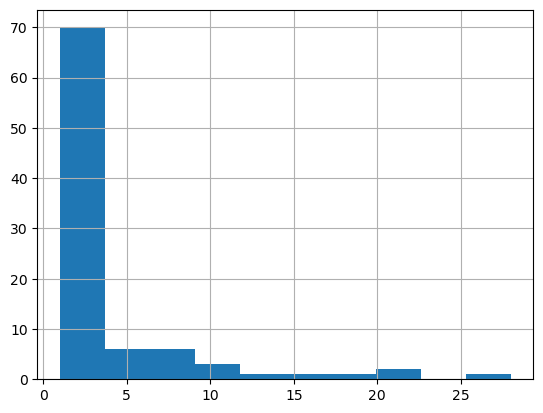

In [ ]:
print(np.sum(procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_CONT'] == 0))
procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_CONT'][procesos_secop_i_data['TOTAL_CONTRACTS_OBRAS_CONT'] > 0].hist()

189


<Axes: >

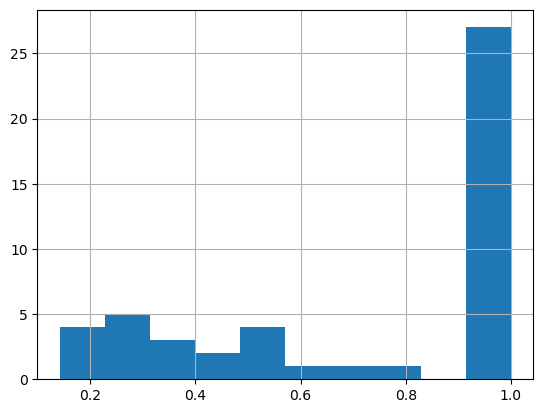

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_DEVIATION_CONT_LAST_Y'] == 0))
procesos_secop_i_data['PROPORTION_DEVIATION_CONT_LAST_Y'][procesos_secop_i_data['PROPORTION_DEVIATION_CONT_LAST_Y'] > 0].hist()

202


<Axes: >

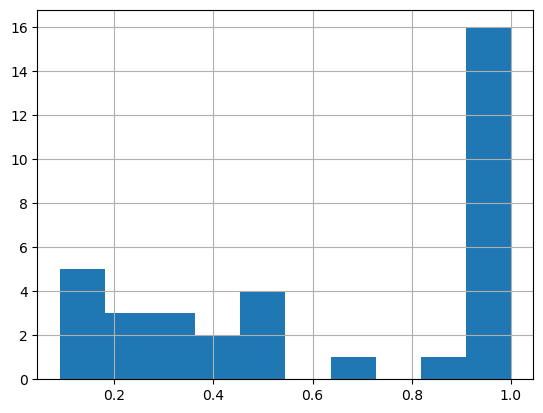

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_COST_DEVIATION_CONT_LAST_Y'] == 0))
procesos_secop_i_data['PROPORTION_COST_DEVIATION_CONT_LAST_Y'][procesos_secop_i_data['PROPORTION_COST_DEVIATION_CONT_LAST_Y'] > 0].hist()

196


<Axes: >

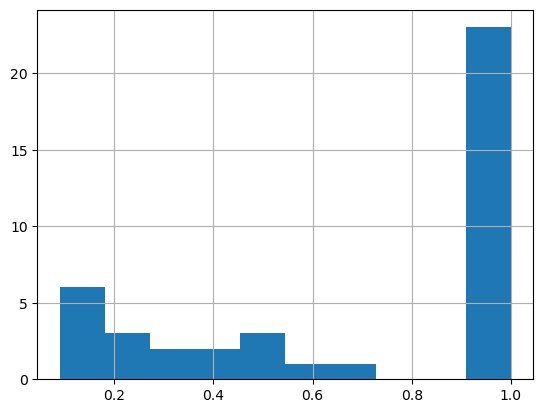

In [ ]:
print(np.sum(procesos_secop_i_data['PROPORTION_TIME_DEVIATION_CONT_LAST_Y'] == 0))
procesos_secop_i_data['PROPORTION_TIME_DEVIATION_CONT_LAST_Y'][procesos_secop_i_data['PROPORTION_TIME_DEVIATION_CONT_LAST_Y'] > 0].hist()

146


<Axes: >

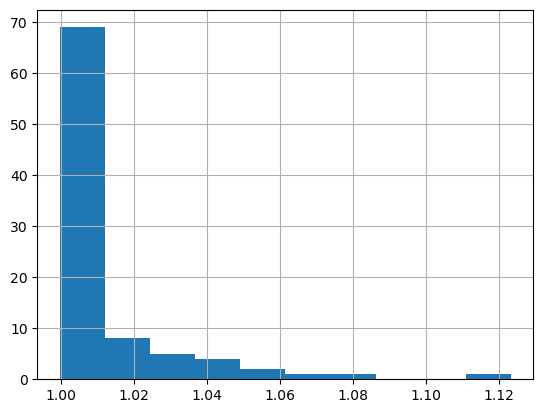

In [ ]:
print(np.sum(procesos_secop_i_data['PROJECT_INTENSITY_NORM_CONT_LAST_Y'] == 0))
procesos_secop_i_data['PROJECT_INTENSITY_NORM_CONT_LAST_Y'][procesos_secop_i_data['PROJECT_INTENSITY_NORM_CONT_LAST_Y'] > 0].hist()

156


<Axes: >

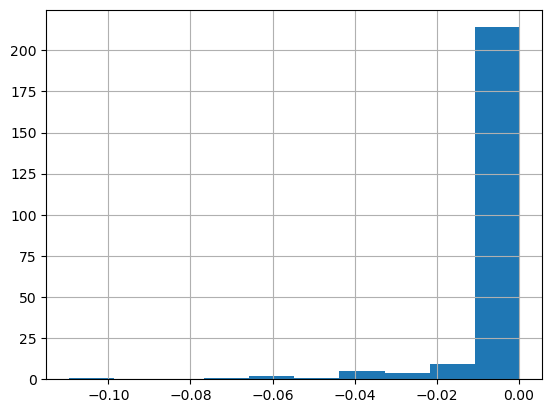

In [ ]:
print(np.sum(procesos_secop_i_data['AWARD_GROWTH_ORIG_CONT_LAST_Y'] == 0))
procesos_secop_i_data['AWARD_GROWTH_ORIG_CONT_LAST_Y'].hist()

## Special visualization

In [ ]:
location_data = pd.read_csv(get_path('data', 'location_contracts.csv'))

interested_col = ['ruta_web', 'latitud', 'longitud', 'categoria_munp_ent',
                  'codigo_municipio_ent', 'codigo_departamento_ent']
location_data = location_data[interested_col].drop_duplicates()

procesos_secop_i_data_loc = pd.merge(procesos_secop_i_data, location_data, how='left',
                left_on='URLPROCESO',
                right_on='ruta_web',
                left_index=False, right_index=False, sort=False)

def summary_loc(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['latitud'] = x['latitud'].mean()
    data['longitud'] = x['longitud'].mean()
    data['value'] = x['PROPORTION_DEVIATIONS_CONT_LAST_Y'].mean()
    data['min'] = x['PROPORTION_DEVIATIONS_CONT_LAST_Y'].min()
    data['max'] = x['PROPORTION_DEVIATIONS_CONT_LAST_Y'].max()
    return pd.Series(data)

procesos_secop_i_data_loc = procesos_secop_i_data_loc.groupby('codigo_municipio_ent').apply(summary_loc).reset_index()

import folium

# Create a folium map centered at an average location
folium_map = folium.Map(location=[4.5709, -74.2973], zoom_start=6)

# Add circles to the map
for idx, row in procesos_secop_i_data_loc.iterrows():
    folium.Circle(
        location=(row['latitud'], row['longitud']),
        radius=row['value']*40000,  # Radius in meters, adjust as needed
        color='',
        fill=True,
        fill_color='blue',
        fill_opacity=0.5  # Adjust the opacity as needed
    ).add_to(folium_map)

# Save the map to an HTML file
folium_map.save('map.html')

# Display the map in a Jupyter Notebook (if using Jupyter)
folium_map

## Variables during project

### First addition time

In [ ]:
ids = list(set(procesos_secop_i_data['ID_ADJUDICACION']))

ids = parse_to_list(ids)

query = get_query('bin/queries', 'request_first_adding_date.sql').format(LIST_UID = ids)

temp_additions_data = etl.extract_data(query, id_data=SECOPI_ADDITIONS_API, api_key=None)

temp_additions_data.head()

El numero de contratos extraidos: 70


,ID_ADJUDICACION,NUM_ADDITION,NUM_ADDITION_VALUE,NUM_ADDITION_TIME,FIRST_ADDITION_AT,FIRST_ADDITION_TIME_AT,FIRST_ADDITION_VALUE_AT
0,10285913,1,0,1,2021-08-25T00:00:00.000,2021-08-25T00:00:00.000,NaN
1,10296834,2,0,2,2020-12-23T00:00:00.000,2020-12-23T00:00:00.000,NaN
2,10326352,1,1,1,2021-10-15T00:00:00.000,2021-10-15T00:00:00.000,2021-10-15T00:00:00.000
3,10502654,3,1,3,2020-07-17T00:00:00.000,2020-07-17T00:00:00.000,2020-10-09T00:00:00.000
4,10910037,1,1,1,2021-04-16T00:00:00.000,2021-04-16T00:00:00.000,2021-04-16T00:00:00.000


In [ ]:
temp_additions_data['FIRST_ADDITION_AT'] = pd.to_datetime(temp_additions_data['FIRST_ADDITION_AT'])
procesos_secop_i_data = pd.merge(procesos_secop_i_data, temp_additions_data,
                                    how='left', on='ID_ADJUDICACION')

procesos_secop_i_data['DAY_DIFF_FIRST_ADDITION'] = (procesos_secop_i_data['FIRST_ADDITION_AT'] - procesos_secop_i_data['START_DATE']) / np.timedelta64(1, 'D')
procesos_secop_i_data['RATIO_FIRST_ADDITION'] = procesos_secop_i_data['DAY_DIFF_FIRST_ADDITION'] / procesos_secop_i_data['ORIGINAL_DEADLINE']

bins = [0, 0.25, 0.5, 0.75, 1, float('inf')]  # Define your bin edges
labels = ['very early', 'early', 'medium', 'late', 'very late']  # Assign labels to bins

# Create a new categorical column based on the bins
procesos_secop_i_data['FIRST_ADITION_TIME_GROUP'] = pd.cut(procesos_secop_i_data['RATIO_FIRST_ADDITION'], bins=bins, labels=labels, right=False)

procesos_secop_i_data['FIRST_ADITION_TIME_GROUP'] = procesos_secop_i_data['FIRST_ADITION_TIME_GROUP'].cat.add_categories('NA').fillna('NA')

procesos_secop_i_data[['URLPROCESO','START_DATE', 'ORIGINAL_DEADLINE', 'FIRST_ADDITION_AT', 'DAY_DIFF_FIRST_ADDITION', 'FIRST_ADITION_TIME_GROUP']].head(5)

,URLPROCESO,START_DATE,ORIGINAL_DEADLINE,FIRST_ADDITION_AT,DAY_DIFF_FIRST_ADDITION,FIRST_ADITION_TIME_GROUP
0,{'url': 'https://www.contratos.gov.co/consultas/detalleProceso.do?numConstancia=17-1-182595'},2017-12-27,90,NaT,NaN,NA
1,{'url': 'https://www.contratos.gov.co/consultas/detalleProceso.do?numConstancia=15-1-138089'},2015-07-06,120,2015-10-27,113.0,late
2,{'url': 'https://www.contratos.gov.co/consultas/detalleProceso.do?numConstancia=15-1-141972'},2015-08-07,120,2015-11-24,109.0,late
3,{'url': 'https://www.contratos.gov.co/consultas/detalleProceso.do?numConstancia=15-1-143842'},2015-09-17,90,NaT,NaN,NA
4,{'url': 'https://www.contratos.gov.co/consultas/detalleProceso.do?numConstancia=19-1-202937'},2019-09-16,90,2019-09-06,-10.0,NA


In [ ]:
procesos_secop_i_data[procesos_secop_i_data['HAVE_DEVIATION']].groupby(['FIRST_ADITION_TIME_GROUP']).apply(summary)

C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_19068\3803707511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  procesos_secop_i_data[procesos_secop_i_data['HAVE_DEVIATION']].groupby(['FIRST_ADITION_TIME_GROUP']).apply(summary)


,unique contracts,value norm avg,cost deviation (%),time duration avg,time deviation (%)
FIRST_ADITION_TIME_GROUP,,,,,
very early,2.0,453.679272,22.327991,120.000000,37.777778
early,2.0,493.250134,13.700542,120.000000,6.666667
medium,2.0,1049.806568,47.716720,135.000000,25.000000
late,13.0,1494.166619,6.594305,98.769231,95.994561
very late,50.0,2263.250557,16.216491,117.000000,63.160714
NA,1.0,1294.883879,20.000000,90.000000,66.666667


In [ ]:
#procesos_secop_i_data['NUM_ADDITION'] = procesos_secop_i_data['NUM_ADDITION'].astype(int)
procesos_secop_i_data.groupby('NUM_ADDITION').apply(summary).sort_values(by='NUM_ADDITION', ascending=True)

,unique contracts,value norm avg,cost deviation (%),time duration avg,time deviation (%)
NUM_ADDITION,,,,,
1,44.0,1126.577650,14.883256,103.068182,35.520382
2,11.0,3777.298722,17.400038,161.272727,83.208219
3,9.0,1834.653255,7.749638,88.333333,112.716049
4,3.0,2075.909810,23.680671,110.000000,174.814815
5,2.0,9158.565884,46.656664,180.000000,250.000000
6,1.0,5698.606692,3.675276,180.000000,94.444444


### Punishment during the project

In [ ]:
# entidad
temp_punishment_entidad_active = temp_punishment_entidad_data[(temp_punishment_entidad_data['END_DATE'] > temp_punishment_entidad_data['PENALTY_DATE']) &
                                                            (temp_punishment_entidad_data['PENALTY_DATE'] > temp_punishment_entidad_data['CONTRACT_DATE'])]\
                                                                .drop_duplicates().groupby('CONTRACT_ID').apply(penalty_summary, '_ENTIDAD_ACTIVE')

#union new rows
procesos_secop_i_data.reset_index(drop = True, inplace = True)
temp_punishment_entidad_active.reset_index(inplace = True)

procesos_secop_i_data = pd.merge(procesos_secop_i_data,
                                 temp_punishment_entidad_active,
                                 how='left', on='CONTRACT_ID')

def summary_punishment_v2(x):
    data = {}
    data['unique contracts'] = x['CONTRACT_ID'].size
    data['value average'] = x['CONTRACT_VALUE_NORM'].mean()
    data['cost deviation'] = x['COST_DEVIATION_NORM'].mean()
    data['time deviation'] = x['TIME_DEVIATION'].mean()
    data['avg penalties to entity during project'] = x['NUM_PENALTIES_ENTIDAD_ACTIVE'].mean()
    data['var penalties to entity during project'] = x['NUM_PENALTIES_ENTIDAD_ACTIVE'].std()

    return pd.Series(data)

procesos_secop_i_data.groupby('HAVE_DEVIATION').apply(summary_punishment_v2)

,unique contracts,value average,cost deviation,time deviation,avg penalties to entity during project,var penalties to entity during project
HAVE_DEVIATION,,,,,,
False,97.0,1881.950384,0.000000,0.000000,19.888889,13.815249
True,70.0,1969.643567,0.154863,0.658789,18.000000,10.283482


In [ ]:
procesos_secop_i_data = procesos_secop_i_data[['CONTRACT_ID','TOTAL_CONTRACTS_OBRAS_ENTITY', 'PROPORTION_DEVIATION_ENTITY_ALL_TIME',
       'PROPORTION_COST_DEVIATION_ENTITY_ALL_TIME',
       'PROPORTION_TIME_DEVIATION_ENTITY_ALL_TIME',
       'PROJECT_INTENSITY_NORM_ENTITY_ALL_TIME',
       'AWARD_GROWTH_ORIG_ENTITY_ALL_TIME', 'TOTAL_CONTRACTS_OBRAS_CONT',
       'PROPORTION_DEVIATION_CONT_ALL_TIME',
       'PROPORTION_COST_DEVIATION_CONT_ALL_TIME',
       'PROPORTION_TIME_DEVIATION_CONT_ALL_TIME',
       'PROJECT_INTENSITY_NORM_CONT_ALL_TIME',
       'AWARD_GROWTH_ORIG_CONT_ALL_TIME']]

In [ ]:
procesos_secop_i_data.to_csv(get_path('data', 'collected_obra_data_v2_5.csv'), index=False)
procesos_secop_i_data.to_csv(get_path('data', 'collected_obra_data_v2_5_excel.csv'), index=False, sep=';', decimal=',')


# ajuste en salario mínimos de casos
# investigar los datos

In [ ]:
procesos_secop_i_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 59 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   CONTRACT_ID                              237 non-null    object        
 1   ENTITY_NAME                              237 non-null    object        
 2   DEPARTMENT                               237 non-null    object        
 3   MUNICIPALITY_TYPE                        237 non-null    object        
 4   PROCESS_TYPE                             237 non-null    object        
 5   CONTRACT_OBJECT                          237 non-null    object        
 6   OBJETC_DETAIL                            237 non-null    object        
 7   ESTIMATED_COST_ORIG                      237 non-null    float64       
 8   CONTRACT_VALUE_ORIG                      237 non-null    float64       
 9   ADDITIONAL_COST_ORIG                     23